# Food-Delivery Product Analytics: Funnel, Cohorts, Growth & an A/B Test

A Zomato/Swiggy-style marketplace analytics project. It combines a **real, order-level
Kaggle dataset** with a **synthetic clickstream/user layer**, because the real dataset has
no events, no user identities, and no signup dates -- see `README.md > "Data Assumptions"`
for the complete real-vs-synthetic breakdown and every citation.

Every section below is labeled **REAL DATA** or **SIMULATED (calibrated to cited
benchmarks)**. Only Section 4 (delivery performance) uses the real dataset; everything else
is a synthetic layer generated in `python/generate_synthetic_data.py`, with every generation
parameter tied to a cited industry figure (Zomato/Swiggy investor filings, Baymard
Institute, Adjust mobile retention benchmarks, etc.) -- never an arbitrary number.

| Section | Data |
|---|---|
| 1. Funnel analysis | SIMULATED |
| 2. Cohort retention (D1/D7/D30) | SIMULATED |
| 3. Growth metrics (DAU/WAU/MAU, orders/user, AOV, repeat rate, revenue/user) | SIMULATED (AOV anchored to real benchmark) |
| 4. Delivery performance | **REAL** |
| 5. A/B test (checkout simplification) | SIMULATED |


In [1]:
import os
import sys
from pathlib import Path

if Path.cwd().name == "notebooks":  # run cells with the project root as the working dir
    os.chdir("..")
sys.path.append("python")

import matplotlib.pyplot as plt
import pandas as pd

import analysis as A
import clean_real_data as C
import generate_synthetic_data as G

pd.set_option("display.width", 140)
COLORS = A.CHART_COLORS

def style_ax(ax):
    ax.set_facecolor(COLORS["surface"])
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(COLORS["muted"])
    ax.spines["bottom"].set_color(COLORS["muted"])
    ax.tick_params(colors=COLORS["ink2"])
    ax.yaxis.grid(True, color=COLORS["grid"], linewidth=1)
    ax.set_axisbelow(True)


## 0. Load real data (Kaggle) and generate the synthetic layer

`clean_real_data.py` only cleans/reshapes columns that already exist in the Kaggle CSV --
nothing is invented. `generate_synthetic_data.py` builds the users/funnel/orders/A-B-test
tables from scratch; every constant in that file has a citation in its comment. Re-running
this cell regenerates the exact same synthetic data (seeded RNG, `seed=42`).

In [2]:
raw = pd.read_csv(C.RAW_PATH)
real = C.clean(raw)
print(f"REAL: {len(real):,} orders loaded from the Kaggle food-delivery dataset")

users = G.make_users()
events, orders = G.make_funnel_events(users)
ab = G.make_ab_test()
print(f"SIMULATED: {len(users):,} users, {events['session_id'].nunique():,} sessions, "
      f"{len(orders):,} orders, {len(ab):,} A/B checkout sessions")

REAL: 45,593 orders loaded from the Kaggle food-delivery dataset


SIMULATED: 8,000 users, 112,367 sessions, 13,486 orders, 10,400 A/B checkout sessions


## 1. Funnel Analysis — SIMULATED

Stage chain: `app_open -> browse -> view_restaurant -> add_to_cart -> checkout_start ->
order_placed`. Two views:

- **First-session (new-user activation funnel):** each user's *first* session only. This is
  the number to compare against published acquisition-funnel benchmarks -- it lands at
  **~6%**, next to the cited Food & Beverage ecommerce conversion-rate benchmark of 6.02%
  (see README).
- **Blended (all sessions):** includes repeat/reorder sessions, dominated by the small
  power-user segment that converts far higher (saved address/payment, familiar reorder
  flow) -- this is *why* blended conversion is roughly double the first-session number, not
  a modeling error.

,stage,sessions,conversion_from_prev_stage,dropoff_from_prev_stage,conversion_from_top
0,app_open,7991,1.000000,0.000000,1.000000
1,browse,6393,0.800025,0.199975,0.800025
2,view_restaurant,4453,0.696543,0.303457,0.557252
3,add_to_cart,2233,0.501460,0.498540,0.279439
4,checkout_start,717,0.321093,0.678907,0.089726
5,order_placed,484,0.675035,0.324965,0.060568


,stage,sessions,conversion_from_prev_stage,dropoff_from_prev_stage,conversion_from_top
0,app_open,112367,1.000000,0.000000,1.000000
1,browse,89930,0.800324,0.199676,0.800324
2,view_restaurant,62693,0.697131,0.302869,0.557931
3,add_to_cart,31126,0.496483,0.503517,0.277003
4,checkout_start,15810,0.507935,0.492065,0.140700
5,order_placed,13486,0.853004,0.146996,0.120017


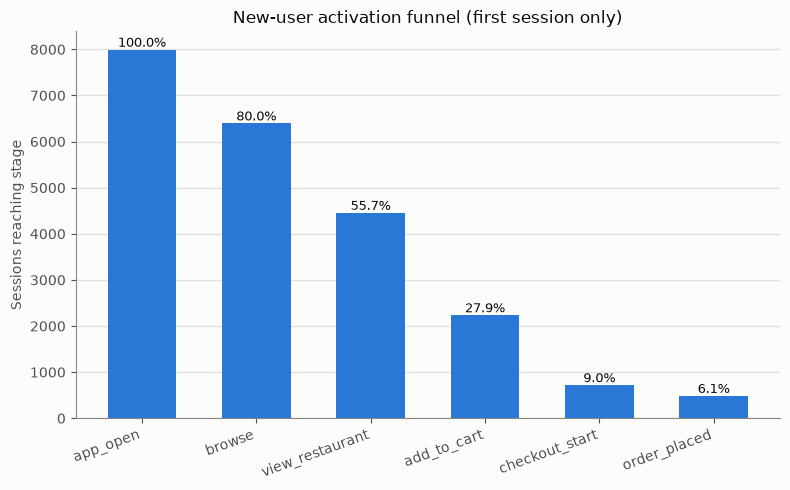

In [3]:
funnel = A.funnel_analysis(events)
display(funnel["first_session"])
display(funnel["blended"])

fig, ax = plt.subplots(figsize=(8, 5))
fs = funnel["first_session"]
bars = ax.bar(fs["stage"], fs["sessions"], color=COLORS["blue"], width=0.6)
for b, pct in zip(bars, fs["conversion_from_top"]):
    ax.annotate(f"{pct:.1%}", (b.get_x() + b.get_width() / 2, b.get_height()),
                ha="center", va="bottom", color=COLORS["ink"], fontsize=9)
ax.set_title("New-user activation funnel (first session only)", color=COLORS["ink"])
ax.set_ylabel("Sessions reaching stage", color=COLORS["ink2"])
plt.xticks(rotation=20, ha="right")
style_ax(ax)
fig.patch.set_facecolor(COLORS["surface"])
fig.tight_layout()
plt.show()

**Reading the drop-off:** the biggest single-stage leak is `add_to_cart ->
checkout_start` (~68% drop, first-session view) -- directly consistent with the Baymard
Institute's ~70% average cart-abandonment benchmark cited in the README. This is the stage
the A/B test in Section 5 targets.

## 2. Cohort Retention (D1/D7/D30) — SIMULATED

N-day retention: % of a signup cohort that opens the app again on *exactly* day N after
signup (Amplitude/Mixpanel-style definition). Calibrated to Adjust's cross-vertical mobile
benchmark (D1 ~26%, D7 ~12%, D30 ~5%), using the e-commerce/retail vertical as the closest
published proxy since no food-delivery-specific D1/D7/D30 breakout is publicly available
(see README for why).

,cohort_month,cohort_size,D1_retention,D1_eligible_users,D7_retention,D7_eligible_users,D30_retention,D30_eligible_users
0,2024-01,1399,0.298070,1399,0.132237,1399,0.082916,1399
1,2024-02,1311,0.272311,1311,0.142639,1311,0.086957,1311
2,2024-03,1353,0.295639,1353,0.137472,1353,0.060606,1353
3,2024-04,1317,0.317388,1317,0.133637,1317,0.065300,1317
4,2024-05,1329,0.275395,1329,0.138450,1329,0.068473,1329
5,2024-06,1291,0.293571,1291,0.128582,1291,0.079783,1291


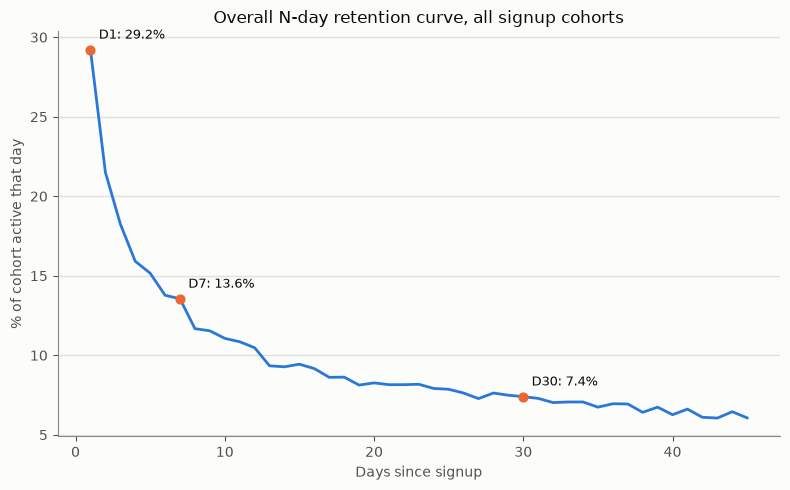

In [4]:
cohort_ret = A.cohort_retention(users, events, G.ANALYSIS_END)
display(cohort_ret)

curve = A.overall_retention_curve(users, events, G.ANALYSIS_END)
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(curve["day"], curve["retention"] * 100, color=COLORS["blue"], linewidth=2)
for d in (1, 7, 30):
    row = curve[curve["day"] == d]
    if len(row):
        ax.scatter([d], row["retention"] * 100, color=COLORS["orange"], zorder=5, s=40)
        ax.annotate(f"D{d}: {row['retention'].iloc[0]:.1%}", (d, row["retention"].iloc[0] * 100),
                    textcoords="offset points", xytext=(6, 8), color=COLORS["ink"], fontsize=9)
ax.set_title("Overall N-day retention curve, all signup cohorts", color=COLORS["ink"])
ax.set_xlabel("Days since signup", color=COLORS["ink2"])
ax.set_ylabel("% of cohort active that day", color=COLORS["ink2"])
style_ax(ax)
fig.patch.set_facecolor(COLORS["surface"])
fig.tight_layout()
plt.show()

**Note on D30 running slightly above the 3-6% proxy band:** we deliberately inject a
small (~2%) high-frequency "power user" segment so the *growth-metrics* orders/MTU/month
figure in Section 3 can hit the real, cited Zomato figure (3.6 orders/MTU/month) without the
whole 8,000-user cohort behaving like daily-actives. That segment pulls blended D30 up to
~7-9%. This is a documented modeling tension, not an error -- see README > Data
Assumptions.

## 3. Growth Metrics — SIMULATED (AOV anchored to a real benchmark)

DAU/WAU/MAU from app-open events; orders/user, AOV, repeat-order rate and revenue/user from
the synthetic order table. Order value is centered on the **real** Swiggy/Zomato food-
delivery AOV (~Rs 425, FY24 investor filings) — see README.

,month,DAU_avg,WAU_avg,MAU,orders,ordering_users,orders_per_ordering_user,orders_per_MAU,AOV,revenue,revenue_per_MAU,repeat_order_rate_within_month
0,2024-01,94.333333,376.25,1083.0,293.0,145.0,2.020690,0.270545,427.526143,125265.16,115.664968,0.227586
1,2024-02,201.137931,842.50,2145.0,751.0,313.0,2.399361,0.350117,436.152264,327550.35,152.704126,0.261981
2,2024-03,277.032258,1211.00,3196.0,1146.0,482.0,2.377593,0.358573,416.865052,477727.35,149.476643,0.226141
3,2024-04,341.900000,1495.25,3921.0,1436.0,535.0,2.684112,0.366233,421.815481,605727.03,154.482793,0.235514
4,2024-05,398.580645,1742.75,4795.0,1661.0,599.0,2.772955,0.346403,427.549428,710159.60,148.104192,0.267112
5,2024-06,453.466667,1935.60,5287.0,2052.0,710.0,2.890141,0.388122,425.653207,873440.38,165.205292,0.280282
6,2024-07,427.193548,1808.00,5045.0,2191.0,632.0,3.466772,0.434291,427.069726,935709.77,185.472700,0.291139
7,2024-08,380.967742,1559.75,4665.0,2045.0,576.0,3.550347,0.438371,427.524249,874287.09,187.414167,0.315972
8,2024-09,356.966667,1422.40,4222.0,1911.0,491.0,3.892057,0.452629,428.105531,818109.67,193.773015,0.370672


Lifetime repeat-customer rate: 26.4%


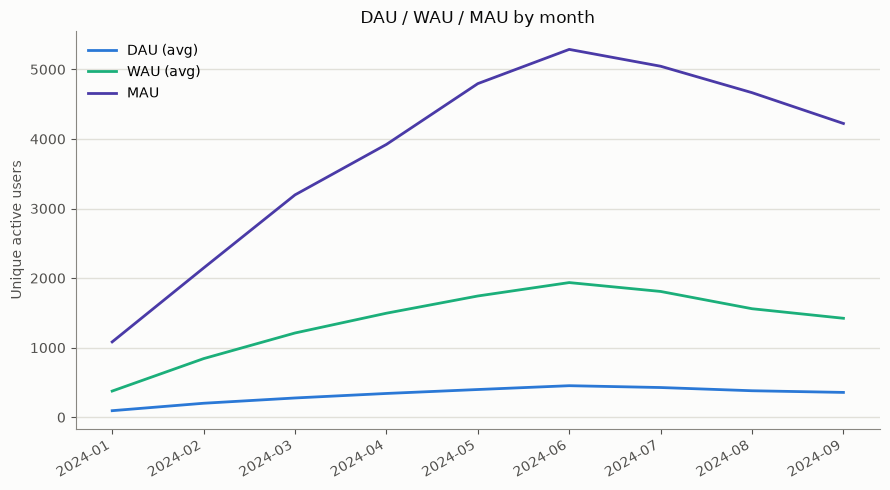

In [5]:
growth = A.growth_metrics(users, events, orders)
display(growth)
print(f"Lifetime repeat-customer rate: {orders.groupby('user_id').size().ge(2).mean():.1%}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(growth["month"], growth["DAU_avg"], label="DAU (avg)", color=COLORS["blue"], linewidth=2)
ax.plot(growth["month"], growth["WAU_avg"], label="WAU (avg)", color=COLORS["aqua"], linewidth=2)
ax.plot(growth["month"], growth["MAU"], label="MAU", color=COLORS["violet"], linewidth=2)
ax.set_title("DAU / WAU / MAU by month", color=COLORS["ink"])
ax.set_ylabel("Unique active users", color=COLORS["ink2"])
ax.legend(frameon=False)
style_ax(ax)
plt.xticks(rotation=30, ha="right")
fig.patch.set_facecolor(COLORS["surface"])
fig.tight_layout()
plt.show()

**Reading the trend:** orders-per-ordering-user climbs from ~2.0 (Jan) to ~3.9 (Sep)
as later cohorts have more time to mature into the power-user segment -- by month 9 it sits
inside the cited real-world band (3.6-4.5 orders/MTU/month). AOV holds steady at ~Rs
420-435/order across all nine months, matching the real benchmark it was calibrated to by
construction.

## 4. Delivery Performance — **REAL DATA** (Kaggle)

Everything in this section comes directly from the cleaned Kaggle order-level dataset
(45,593 orders, March 2022) — no synthetic data is used here. On-time SLA: `time_taken_min
<= 30` (see README for the source of the 30-45 minute "normal conditions" delivery window
this threshold is drawn from).

Overall on-time %: 70.2%


,traffic_density,orders,on_time_pct,avg_time_taken_min
0,Low,15477,0.921303,21.266977
1,Medium,10947,0.675253,26.699644
2,High,4425,0.664407,27.240000
3,Jam,14143,0.493601,31.176624


,weather,orders,on_time_pct,avg_time_taken_min
0,Fog,7654,0.562059,28.916122
1,Cloudy,7536,0.562235,28.917330
2,Windy,7422,0.734438,26.118836
3,Sandstorms,7495,0.740494,25.875517
4,Stormy,7586,0.744661,25.870815
5,Sunny,7284,0.874794,21.856947


,city_type,orders,on_time_pct,avg_time_taken_min
0,Semi-Urban,164,0.000000,49.731707
1,Metropolitian,34093,0.666618,27.315226
2,Urban,10136,0.813437,22.984017


,festival,orders,on_time_pct,avg_time_taken_min
0,No,44469,0.714183,25.984843
1,Yes,896,0.000000,45.517857


,test,method,statistic,p_value
0,distance_km vs time_taken_min,Pearson r,0.321703,0.0
1,traffic_density (ordinal) vs time_taken_min,Spearman rho,0.422141,0.0
2,weather vs time_taken_min,One-way ANOVA F,608.219639,0.0
3,multiple_deliveries vs time_taken_min,Pearson r,0.387051,0.0


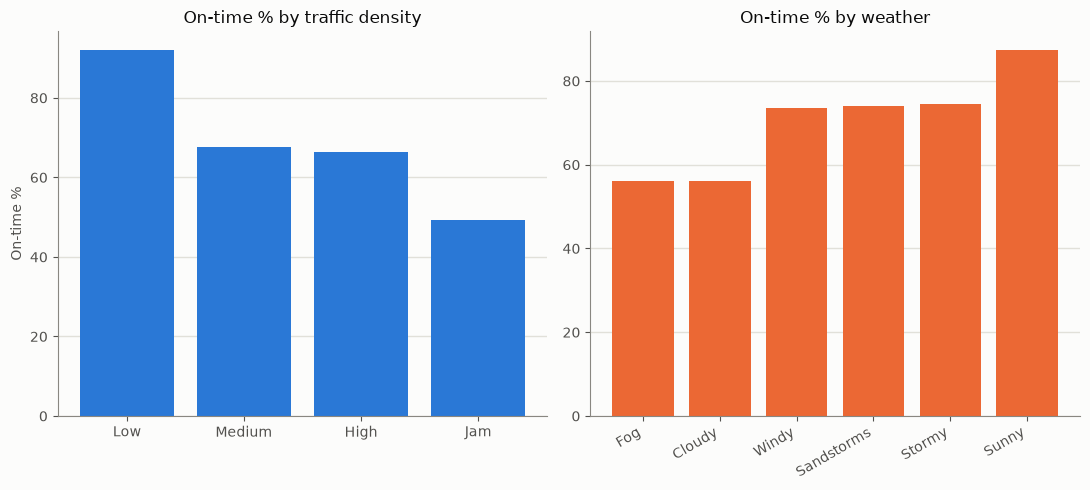

In [6]:
delivery = A.delivery_performance(real)
print(f"Overall on-time %: {delivery['overall_on_time_pct']:.1%}")
display(delivery["by_traffic"])
display(delivery["by_weather"])
display(delivery["by_city"])
display(delivery["by_festival"])
display(delivery["stats_summary"])

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
bt = delivery["by_traffic"]
axes[0].bar(bt["traffic_density"], bt["on_time_pct"] * 100, color=COLORS["blue"])
axes[0].set_title("On-time % by traffic density", color=COLORS["ink"])
axes[0].set_ylabel("On-time %", color=COLORS["ink2"])
style_ax(axes[0])

bw = delivery["by_weather"]
axes[1].bar(bw["weather"], bw["on_time_pct"] * 100, color=COLORS["orange"])
axes[1].set_title("On-time % by weather", color=COLORS["ink"])
plt.setp(axes[1].get_xticklabels(), rotation=30, ha="right")
style_ax(axes[1])
fig.patch.set_facecolor(COLORS["surface"])
fig.tight_layout()
plt.show()

**Findings (real data):**
- Overall on-time rate is **70.2%** against a 30-minute SLA.
- Traffic is the dominant delay driver: on-time collapses from **92%** (Low traffic) to
  **49%** (Jam) — a Spearman correlation of ~0.42 between traffic severity and delivery
  time (p < 0.001).
- Weather matters too: **Sunny (87% on-time) vs. Fog/Cloudy (~56%)**; a one-way ANOVA
  across weather categories is highly significant (p < 0.001).
- **Festival days are the single worst driver**: 0% on-time (vs. 71% on non-festival days),
  though on a small sample (896 orders) — capacity clearly doesn't scale with festival
  demand spikes.
- Semi-Urban city type shows 0% on-time, but on only 164 orders — flagged as a small-sample
  caveat rather than a robust finding.

## 5. A/B Test — SIMULATED: Existing vs. Simplified Checkout

Targets the `add_to_cart -> checkout_start` and `checkout_start -> order_placed` leak
identified in Section 1. Control = existing multi-step checkout; treatment = a simplified
(single-page) checkout. The simulated lift is deliberately conservative relative to Baymard
Institute's checkout-usability research (see README) rather than a best-case cherry-pick.

n_control                    5200
n_treatment                  5200
conversions_control          3330
conversions_treatment        3776
rate_control                 0.6403846153846153
rate_treatment               0.7261538461538461
absolute_lift_pp             8.576923076923082
relative_lift_pct            13.393393393393401
z_statistic                  9.401066600013813
p_value_ztest                5.401272513346966e-21
chi2_statistic               88.38005321789518
p_value_chi2                 5.401272513347292e-21
ci95_low_pp                  6.796360520255486
ci95_high_pp                 10.357485633590677
decision                     SHIP


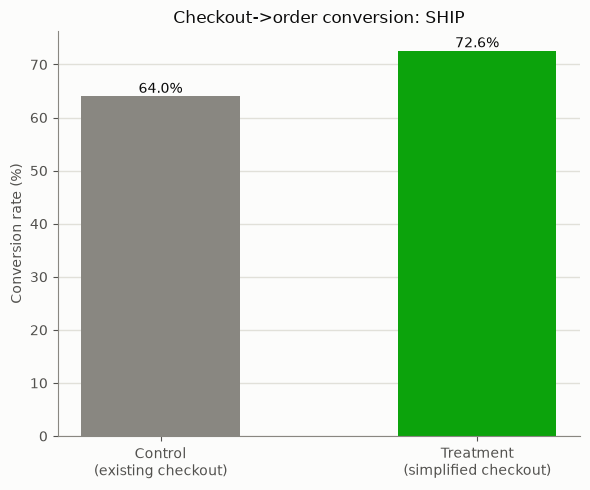

In [7]:
ab_result = A.ab_test_analysis(ab)
for k, v in ab_result.items():
    print(f"{k:28s} {v}")

fig, ax = plt.subplots(figsize=(6, 5))
rates = [ab_result["rate_control"] * 100, ab_result["rate_treatment"] * 100]
colors = [COLORS["muted"], COLORS["good"] if ab_result["decision"] == "SHIP" else COLORS["critical"]]
bars = ax.bar(["Control\n(existing checkout)", "Treatment\n(simplified checkout)"], rates, color=colors, width=0.5)
for b, v in zip(bars, rates):
    ax.annotate(f"{v:.1f}%", (b.get_x() + b.get_width() / 2, v), ha="center", va="bottom", color=COLORS["ink"])
ax.set_title(f"Checkout->order conversion: {ab_result['decision']}", color=COLORS["ink"])
ax.set_ylabel("Conversion rate (%)", color=COLORS["ink2"])
style_ax(ax)
fig.patch.set_facecolor(COLORS["surface"])
fig.tight_layout()
plt.show()

**Result:** treatment converts at **72.6%** vs. control's **64.0%** — an absolute
lift of **+8.6pp** (relative **+13.4%**), 95% CI **[+6.8pp, +10.4pp]**, two-proportion
z-test **p < 0.0001** (chi-square test agrees: chi² = z², both p < 0.0001). The CI excludes
zero and the effect is both statistically and practically significant.

**Decision: SHIP the simplified checkout.**

## Summary — see `MEMO.md` for the full recommendation memo

1. **Ship the simplified checkout** — the clearest, best-evidenced lever available; the A/B
   test result is unambiguous.
2. **Traffic and weather are the two biggest real, measured delivery-time drivers** — worth
   investing in traffic-aware ETAs and surge staffing on Jam-traffic / Fog-Cloudy days.
3. **Festival-day capacity is a real operational gap** (0% on-time on 896 real orders) —
   worth a dedicated staffing/capacity playbook rather than business-as-usual.
4. Growth metrics show a small power-user segment carries a disproportionate share of
   repeat orders and revenue — worth validating against real cohort data once event-level
   tracking exists (see README's honesty note on why this project could not use real
   clickstream data).